<a href="https://colab.research.google.com/github/Dynamic1610/FUTURE_DS_01/blob/main/Superstore_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Superstore Sales Performance Analytics

**Future Interns — Data Science & Analytics Task 1**


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


## 1. Load the dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file_name = "Sample - Superstore.csv"
df = pd.read_csv(file_name, encoding="latin1")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Clean and prepare the data

We remove extra spaces, convert the two date columns to real dates, and treat Postal Code as text instead of a number.


In [4]:
df.columns = df.columns.str.strip()

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.replace("\xa0", " ", regex=False).str.strip()

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Postal Code"] = df["Postal Code"].astype("Int64").astype(str).str.zfill(5)

# Extra date fields make trend analysis easier.
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

print("Cleaning complete.")


Cleaning complete.


## 3. Quick data-quality check

This confirms whether any important values are missing or duplicated.


In [5]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isna().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())
print("Orders:", df["Order ID"].nunique())
print("Customers:", df["Customer ID"].nunique())
print("Order-date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())


Rows: 9994
Columns: 24
Missing values: 0
Exact duplicate rows: 0
Orders: 5009
Customers: 793
Order-date range: 2014-01-03 to 2017-12-30


## 4. Core business KPIs


In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_units = df["Quantity"].sum()
profit_margin = total_profit / total_sales * 100
average_order_value = total_sales / total_orders

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Units Sold: {total_units:,}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Average Order Value: ${average_order_value:,.2f}")


Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Units Sold: 37,873
Profit Margin: 12.47%
Average Order Value: $458.61


## 5. Monthly sales and profit trend

This shows growth over time and helps identify seasonal patterns.


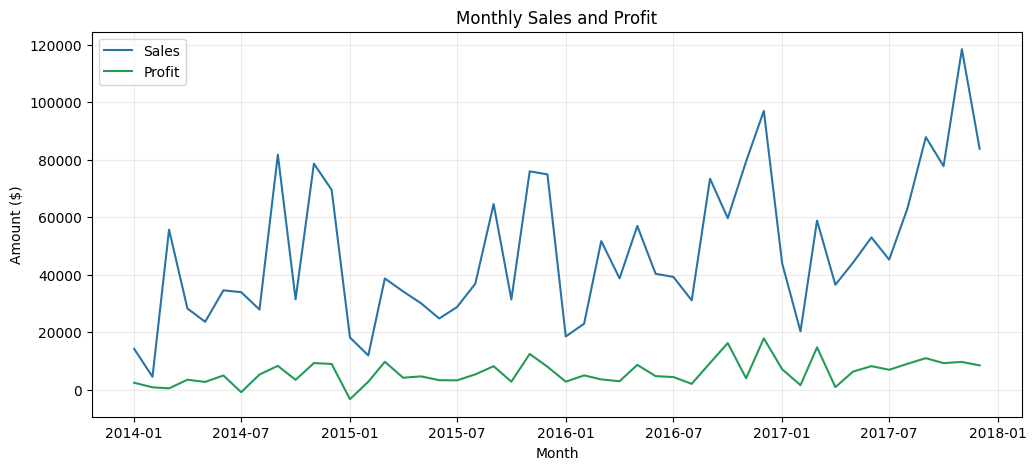

In [7]:
monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
      .reset_index()
)
monthly["Order Date"] = monthly["Order Date"].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly["Order Date"], monthly["Sales"], label="Sales", color="#2874A6")
plt.plot(monthly["Order Date"], monthly["Profit"], label="Profit", color="#239B56")
plt.title("Monthly Sales and Profit")
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. Category and sub-category performance

Sales alone can be misleading, so we compare sales with profit.


,Sales,Profit,Profit Margin %
Category,,,
Technology,836154.03,145454.95,17.40
Office Supplies,719047.03,122490.80,17.04
Furniture,741999.80,18451.27,2.49


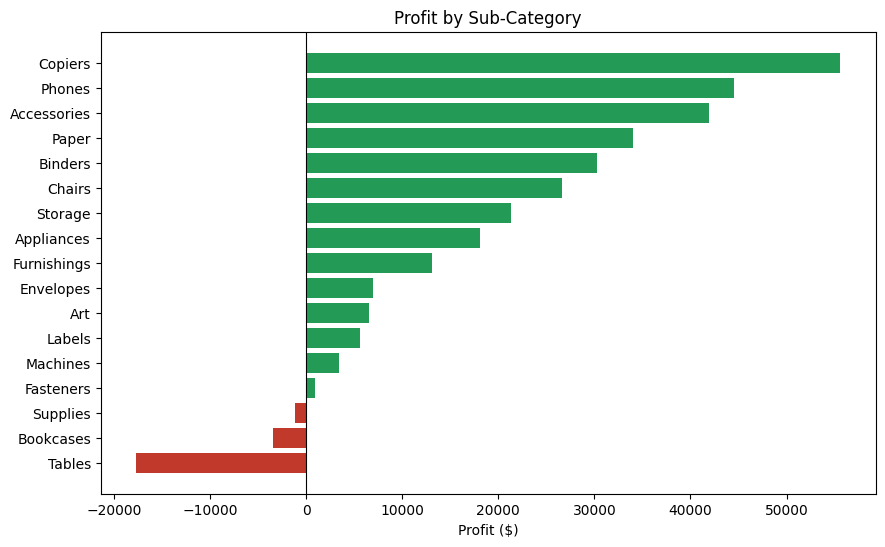

In [8]:
category_summary = (
    df.groupby("Category")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
)
category_summary["Profit Margin %"] = category_summary["Profit"] / category_summary["Sales"] * 100
display(category_summary.round(2).sort_values("Profit", ascending=False))

subcategory_summary = (
    df.groupby("Sub-Category")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
      .sort_values("Profit")
)

colors = ["#C0392B" if profit < 0 else "#239B56" for profit in subcategory_summary["Profit"]]
plt.figure(figsize=(10, 6))
plt.barh(subcategory_summary.index, subcategory_summary["Profit"], color=colors)
plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


## 7. Discount analysis

This checks whether discounts are helping or damaging profitability.


,Sales,Profit
Discount Band,,
0%,1087908.47,320987.60
1-20%,846522.24,100785.47
21-40%,234137.90,-35817.47
41-60%,71048.21,-28944.19
60%+,57584.04,-70614.40


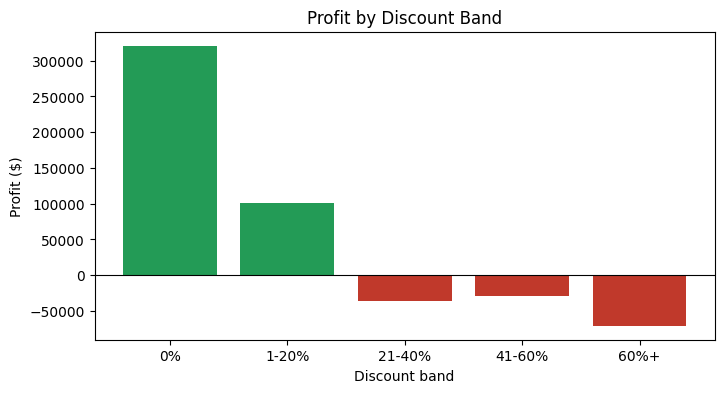

In [9]:
df["Discount Band"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 1],
    labels=["0%", "1-20%", "21-40%", "41-60%", "60%+"]
)

discount_summary = (
    df.groupby("Discount Band", observed=True)
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
)
display(discount_summary.round(2))

colors = ["#239B56" if profit >= 0 else "#C0392B" for profit in discount_summary["Profit"]]
plt.figure(figsize=(8, 4))
plt.bar(discount_summary.index.astype(str), discount_summary["Profit"], color=colors)
plt.title("Profit by Discount Band")
plt.xlabel("Discount band")
plt.ylabel("Profit ($)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()


## 8. Regional performance

This compares where the business earns the most profit.


,Sales,Profit,Orders,Profit Margin %
Region,,,,
West,725457.82,108418.45,1611,14.94
East,678781.24,91522.78,1401,13.48
South,391721.90,46749.43,822,11.93
Central,501239.89,39706.36,1175,7.92


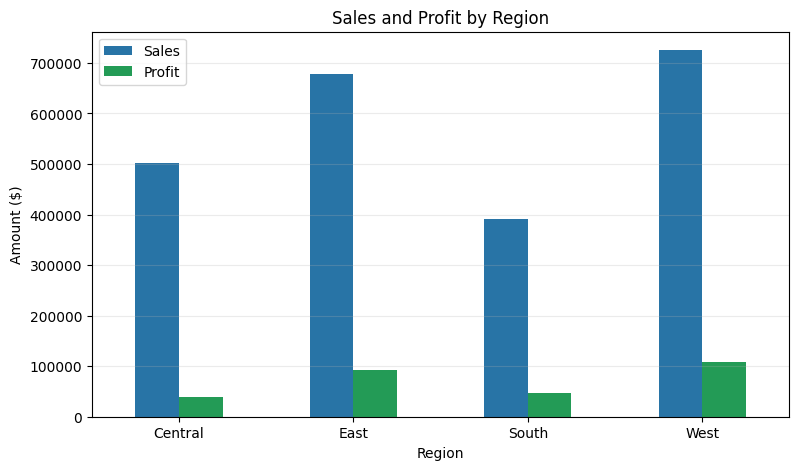

In [10]:
region_summary = (
    df.groupby("Region")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"))
)
region_summary["Profit Margin %"] = region_summary["Profit"] / region_summary["Sales"] * 100
display(region_summary.round(2).sort_values("Profit", ascending=False))

region_summary[["Sales", "Profit"]].plot(kind="bar", figsize=(9, 5), color=["#2874A6", "#239B56"])
plt.title("Sales and Profit by Region")
plt.ylabel("Amount ($)")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()


## 9. Best and worst products

These products are useful for promotion decisions and pricing reviews.


In [11]:
product_summary = (
    df.groupby("Product Name")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum"))
)

top_products = product_summary.sort_values("Profit", ascending=False).head(10)
loss_products = product_summary.sort_values("Profit").head(10)

print("Top 10 products by profit")
display(top_products.round(2))

print("Top 10 loss-making products")
display(loss_products.round(2))


Top 10 products by profit


,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,31
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38
Canon PC1060 Personal Laser Copier,11619.83,4570.93,19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,12
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,11
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,11
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28,24
Ibico EPK-21 Electric Binding System,15875.92,3345.28,13


Top 10 loss-making products


,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97,9
Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18
Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.64,-2876.12,27
Bush Advantage Collection Racetrack Conference Table,9544.72,-1934.40,33
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18,22
Balt Solid Wood Round Tables,6518.75,-1201.06,19


## 10. Final business insights and recommendations

1. **Protect the successful Technology category.** It generates the highest sales and profit.
2. **Review Furniture pricing and costs.** It has high sales but a very low profit margin; Tables and Bookcases lose money.
3. **Control discounts above 20%.** Every discount band above 20% produces an overall loss in this dataset.
4. **Investigate the Central region.** It has the lowest regional profit margin.
5. **Promote proven profitable products.** The Canon imageCLASS 2200 Advanced Copier is the leading product by profit, while several 3D printers and conference tables should be reviewed.

These are recommendations based on the data, not assumptions.


## 11. Export the cleaned data for Power BI

Run this only when you are ready to download the cleaned file.


In [13]:
from google.colab import files

df.to_csv("Superstore_Cleaned.csv", index=False, encoding="utf-8-sig")
files.download("Superstore_Cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>